# Solvent Mixtures via PCA Interpolation

This tutorial shows how to represent **mixed-solvent systems** in EDBO+ by interpolating
the PCA coordinates of pure solvents.

### The idea

Each pure solvent is described by PC1–PC4 from the bundled `data/Solvent_PC_clean.csv`
table. For a blend with fraction $f$ of solvent A and $1-f$ of B, the mixture's
coordinates are the **weighted average**:

$$\mathrm{PC}_{\mathrm{mix}} = f \cdot \mathrm{PC}_A + (1-f)\cdot \mathrm{PC}_B$$

Because PCA is a *linear* transform, this is mathematically identical to averaging the
underlying physicochemical descriptors — so a blend simply lands on the straight line
between its two pure components in PC space.

### Chemistry caveat

Fractions are treated as a **linear, mole-like basis** and used exactly as given (no
volume→mole conversion). This is exact for averaging molecular descriptors and a good
first approximation for blends, but it does **not** capture non-ideal bulk behaviour
(e.g. non-linear dielectric constants). Treat interpolated blends as a chemically
reasonable exploratory encoding, not a rigorous mixture model.


## 1. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from edbo.plus.optimizer_botorch import EDBOplus
from edbo.plus.mixtures import make_mixtures, binary_ratio_grid, combine_lookups

FEATURES = ['PC1', 'PC2', 'PC3', 'PC4']
A = 'DMSO [Dimethylsulfoxide]'   # names must match the lookup table exactly
B = 'DCM [Dichloromethane]'


## 2. Named blends with `make_mixtures`

Pass a dict mapping each blend name to its `{solvent: weight}` recipe. Weights are
normalized to sum to 1, so `{A: 1, B: 1}` means 50:50 and `{A: 3, B: 1}` means 75:25.


In [2]:
named = make_mixtures({
    'DMSO/DCM 50:50': {A: 1, B: 1},
    'DMSO/DCM 75:25': {A: 3, B: 1},
    'DMSO/DCM 25:75': {A: 1, B: 3},
})
named


,Name,PC1,PC2,PC3,PC4,PC5
0,DMSO/DCM 50:50,-3.906705,-1.267685,-2.667915,1.933175,1.281122
1,DMSO/DCM 75:25,-5.532357,1.368812,-3.333557,2.260598,0.922402
2,DMSO/DCM 25:75,-2.281052,-3.904182,-2.002273,1.605752,1.639841


## 3. Ratio scans with `binary_ratio_grid`

To let EDBO+ search over a blend ratio, generate a grid. The `fractions` are the fraction
of the **first** solvent; `0` → pure B and `1` → pure A, so the pure endpoints are included
automatically.


In [3]:
grid = binary_ratio_grid(A, B, fractions=[0, 0.25, 0.5, 0.75, 1.0])
grid


,Name,PC1,PC2,PC3,PC4,PC5
0,DMSO/DCM 0:100,-0.655400,-6.540680,-1.336630,1.278330,1.998560
1,DMSO/DCM 25:75,-2.281052,-3.904182,-2.002273,1.605752,1.639841
2,DMSO/DCM 50:50,-3.906705,-1.267685,-2.667915,1.933175,1.281122
3,DMSO/DCM 75:25,-5.532357,1.368812,-3.333557,2.260598,0.922402
4,DMSO/DCM 100:0,-7.158010,4.005310,-3.999200,2.588020,0.563683


## 4. Blends lie on the line between pure solvents

Plotting the grid in PC1–PC2 space confirms the geometry: every blend sits on the straight
line connecting the two pure solvents, spaced by its mixing ratio.


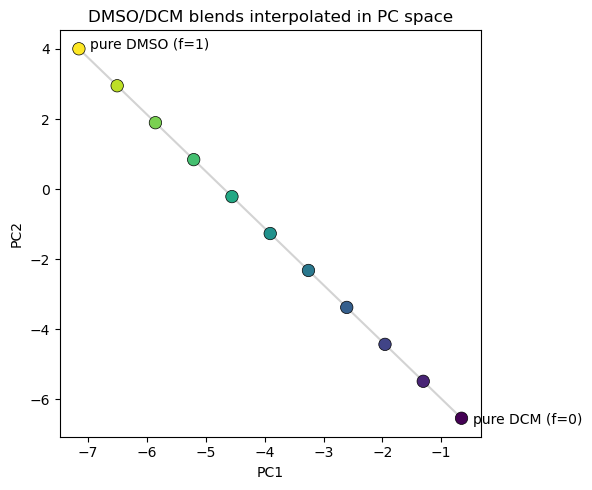

In [4]:
fine = binary_ratio_grid(A, B, fractions=np.linspace(0, 1, 11))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fine['PC1'], fine['PC2'], '-', color='lightgray', zorder=1)
ax.scatter(fine['PC1'], fine['PC2'], c=np.linspace(0, 1, 11), cmap='viridis',
           s=80, zorder=2, edgecolor='k', linewidth=0.5)

# annotate the pure endpoints
ax.annotate('pure DCM (f=0)', (fine['PC1'].iloc[0], fine['PC2'].iloc[0]),
            textcoords='offset points', xytext=(8, -4))
ax.annotate('pure DMSO (f=1)', (fine['PC1'].iloc[-1], fine['PC2'].iloc[-1]),
            textcoords='offset points', xytext=(8, 0))
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('DMSO/DCM blends interpolated in PC space')
plt.tight_layout(); plt.show()


## 5. Mixing pure solvents and blends in one scope

Use `combine_lookups` to stack pure-solvent rows and blend rows into a single lookup, so the
optimizer can choose pure solvents *or* blends. Duplicate names are dropped automatically.


In [5]:
from edbo.plus.scope_generator import _load_solvent_lookup

pures = _load_solvent_lookup()
pures = pures[pures['Name'].isin(['Toluene', 'Acetone'])][['Name'] + FEATURES]

lookup = combine_lookups(pures, grid[['Name'] + FEATURES])
lookup


,Name,PC1,PC2,PC3,PC4
0,Acetone,-3.043410,-1.912590,-3.565670,-1.794000
1,Toluene,4.150920,-3.704360,-1.086880,0.976390
2,DMSO/DCM 0:100,-0.655400,-6.540680,-1.336630,1.278330
3,DMSO/DCM 25:75,-2.281052,-3.904182,-2.002273,1.605752
4,DMSO/DCM 50:50,-3.906705,-1.267685,-2.667915,1.933175
5,DMSO/DCM 75:25,-5.532357,1.368812,-3.333557,2.260598
6,DMSO/DCM 100:0,-7.158010,4.005310,-3.999200,2.588020


## 6. End-to-end optimization over a blend ratio

Here we let EDBO+ optimize the DMSO/DCM ratio (plus temperature) against a single objective.
We use a fine ratio grid, seed a few observations, and then read the model's predicted yield
across the whole blend axis.

> The synthetic "yield" used here peaks at a 50:50 blend on purpose, to illustrate the case
> where an intermediate mixture beats both pure solvents.


In [6]:
blend = binary_ratio_grid(A, B, fractions=np.round(np.linspace(0, 1, 11), 2))

components = {
    'solvent':     blend['Name'].tolist(),
    'temperature': [25, 50],
}

EDBOplus().generate_reaction_scope(
    components=components,
    encodings={'solvent': {'file': blend, 'key': 'Name', 'features': FEATURES}},
    filename='mixtures_scope.csv',
    check_overwrite=False,
)


Generating a reaction scope...
The scope was generated and contains 22 possible reactions!


,solvent,temperature,PC1,PC2,PC3,PC4
0,DMSO/DCM 0:100,25,-0.655400,-6.540680,-1.336630,1.278330
1,DMSO/DCM 0:100,50,-0.655400,-6.540680,-1.336630,1.278330
2,DMSO/DCM 10:90,25,-1.305661,-5.486081,-1.602887,1.409299
3,DMSO/DCM 10:90,50,-1.305661,-5.486081,-1.602887,1.409299
4,DMSO/DCM 20:80,25,-1.955922,-4.431482,-1.869144,1.540268
5,DMSO/DCM 20:80,50,-1.955922,-4.431482,-1.869144,1.540268
6,DMSO/DCM 30:70,25,-2.606183,-3.376883,-2.135401,1.671237
7,DMSO/DCM 30:70,50,-2.606183,-3.376883,-2.135401,1.671237
8,DMSO/DCM 40:60,25,-3.256444,-2.322284,-2.401658,1.802206
9,DMSO/DCM 40:60,50,-3.256444,-2.322284,-2.401658,1.802206


In [7]:
# Parse the fraction of solvent A out of each blend name ('DMSO/DCM 50:50' -> 0.50)
def fraction_of_A(name):
    return float(name.split()[-1].split(':')[0]) / 100.0

scope = pd.read_csv('mixtures_scope.csv')
scope['fA'] = scope['solvent'].map(fraction_of_A)

# Synthetic ground-truth yield: peaks at a 50:50 blend, mild temperature effect
def synthetic_yield(fA, T):
    return 90 * np.exp(-((fA - 0.5) / 0.25) ** 2) + (T - 25) / 50 * 5 + 3

# Seed six observations spread across the ratio axis
scope['yield'] = 'PENDING'
for i in [0, 5, 10, 11, 16, 21]:
    row = scope.iloc[i]
    scope.at[i, 'yield'] = round(synthetic_yield(row['fA'], row['temperature']), 2)

scope.drop(columns='fA').to_csv('mixtures_scope.csv', index=False)
print(f"Seeded {(scope['yield'] != 'PENDING').sum()} observations.")


Seeded 6 observations.


In [8]:
EDBOplus().run(
    filename='mixtures_scope.csv',
    objectives=['yield'],
    objective_mode=['max'],
    exclude_columns=['solvent'],   # PC1-PC4 carry the blend information
    batch=4,
)


This run will optimize for the following objectives: ['yield']
The following features will be used: ['PC3', 'PC1', 'temperature', 'PC4', 'PC2']
Generating surrogate model...


/Users/sergiy/miniforge3/envs/edbo_env/lib/python3.9/site-packages/gpytorch/lazy/triangular_lazy_tensor.py:124: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2190.)
  res = torch.triangular_solve(right_tensor, self.evaluate(), upper=self.upper).solution


Model generated!
Optimizing acqusition function...
Acquisition function optimized.
Predictions and expected improvement obtained.
Run finished!


,solvent,temperature,PC1,PC2,PC3,PC4,yield,priority
19,DMSO/DCM 90:10,50,-6.507749,2.950711,-3.732943,2.457051,PENDING,1.0
2,DMSO/DCM 10:90,25,-1.305661,-5.486081,-1.602887,1.409299,PENDING,1.0
20,DMSO/DCM 100:0,25,-7.158010,4.005310,-3.999200,2.588020,PENDING,1.0
1,DMSO/DCM 0:100,50,-0.655400,-6.540680,-1.336630,1.278330,PENDING,1.0
18,DMSO/DCM 90:10,25,-6.507749,2.950711,-3.732943,2.457051,PENDING,0.0
17,DMSO/DCM 80:20,50,-5.857488,1.896112,-3.466686,2.326082,PENDING,0.0
15,DMSO/DCM 70:30,50,-5.207227,0.841513,-3.200429,2.195113,PENDING,0.0
14,DMSO/DCM 70:30,25,-5.207227,0.841513,-3.200429,2.195113,PENDING,0.0
13,DMSO/DCM 60:40,50,-4.556966,-0.213086,-2.934172,2.064144,PENDING,0.0
12,DMSO/DCM 60:40,25,-4.556966,-0.213086,-2.934172,2.064144,PENDING,0.0


### Predicted yield across the blend axis

The GP interpolates smoothly over the continuous PC representation, recovering the peak at an
intermediate blend — something one-hot encoding (which treats each blend as unrelated) could
not do.


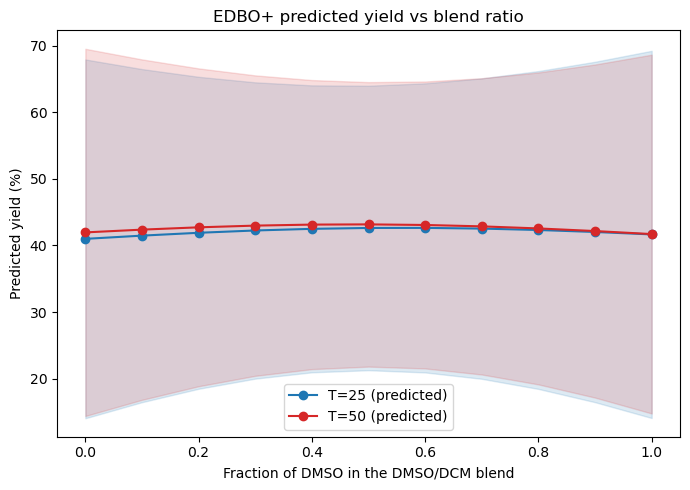

In [9]:
pred = pd.read_csv('pred_mixtures_scope.csv')
pred['fA'] = pred['solvent'].map(fraction_of_A)
pred['yield_predicted_mean'] = pred['yield_predicted_mean'].astype(float)
pred['yield_predicted_std_dev'] = pred['yield_predicted_std_dev'].astype(float)

fig, ax = plt.subplots(figsize=(7, 5))
for T, color in [(25, 'tab:blue'), (50, 'tab:red')]:
    s = pred[pred['temperature'] == T].sort_values('fA')
    ax.plot(s['fA'], s['yield_predicted_mean'], '-o', color=color, label=f'T={T} (predicted)')
    ax.fill_between(s['fA'],
                    s['yield_predicted_mean'] - s['yield_predicted_std_dev'],
                    s['yield_predicted_mean'] + s['yield_predicted_std_dev'],
                    color=color, alpha=0.15)

ax.set_xlabel('Fraction of DMSO in the DMSO/DCM blend')
ax.set_ylabel('Predicted yield (%)')
ax.set_title('EDBO+ predicted yield vs blend ratio')
ax.legend()
plt.tight_layout(); plt.show()


In [10]:
# The next experiments EDBO+ suggests (priority = 1)
result = pd.read_csv('mixtures_scope.csv')
result[result['priority'] == 1][['solvent', 'temperature', 'yield', 'priority']]


,solvent,temperature,yield,priority
0,DMSO/DCM 90:10,50,PENDING,1.0
1,DMSO/DCM 10:90,25,PENDING,1.0
2,DMSO/DCM 100:0,25,PENDING,1.0
3,DMSO/DCM 0:100,50,PENDING,1.0


## Summary

| Helper | Use |
|---|---|
| `make_mixtures({name: {solvent: weight}})` | Explicit named blends with arbitrary recipes |
| `binary_ratio_grid(A, B, fractions=...)` | Auto grid of binary blends, pure endpoints included |
| `combine_lookups(*tables)` | Stack pure solvents and blends into one lookup |

All three return a lookup-shaped DataFrame (`Name, PC1, PC2, ...`). Feed it to
`generate_reaction_scope` via `encodings`, and pass the label column to `exclude_columns`
in `run()` so the model uses the interpolated PC features. **No changes to the optimizer
are required** — mixtures reuse the same PCA encoding path as pure solvents.
